# HNSW benchmark: 1.06M EU-law chunks

**Corpus:** 43,106 EU acts in force · 1,062,613 chunks · `bge-base-en-v1.5` (768 dims, `halfvec`) · PostgreSQL 16 + pgvector

## Experiment 1: building the index

```sql
SET maintenance_work_mem = '2GB';
SET max_parallel_maintenance_workers = 3;
CREATE INDEX chunks_embedding_hnsw ON chunks
  USING hnsw (embedding halfvec_cosine_ops) WITH (m = 16, ef_construction = 64);
```

| Build time | Index size | Chunk data |
|---|---|---|
| **42 min 27 s** | **1,935 MB** | 1,310 MB |

- The graph exceeded 2 GB of build memory at 91% of the vectors; the rest was built on disk, which slowed the build.
- The index is larger than the data it indexes.

## Experiment 2: exact search (no index)

100 questions from 20 areas of EU law, each compared with **all 1,062,613 vectors** (`SET enable_indexscan = off`).

**Gives us:**
- **the baseline speed** without an index,
- **the ground truth**: the true top 10 chunks per question, saved to `results/exact_truth.json` and used to score HNSW:

$$\text{recall@10} = \frac{|\,\text{HNSW top 10} \cap \text{exact top 10}\,|}{10}$$

| p50 | p95 | min / max |
|---|---|---|
| **5.6 s** | **23.5 s** | 1.9 s / 36.8 s |

Latency depends heavily on caching: ~2 s when the table is in memory, up to ~37 s when it is read from disk.

#### 1. setup

In [14]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import psycopg
from config import settings # reads DATABASE_URL etc. from .env

ROOT = Path.cwd().resolve().parent          # benchmarks_hnsw/ -> repository root
sys.path.insert(0, str(ROOT / "ingest"))

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

conn = psycopg.connect(settings.database_url, autocommit=True)
print(conn.execute("SELECT count(*) FROM chunks").fetchone()[0], "chunks")

1062613 chunks


#### 2. load the questions

In [8]:
lines = Path("queries.txt").read_text().splitlines()
questions = [q.strip() for q in lines if q.strip() and not q.startswith("#")]
print(len(questions), "questions")

100 questions


#### 3. embed the questions (once, cached to a file)

In [9]:
from sentence_transformers import SentenceTransformer

PREFIX = "Represent this sentence for searching relevant passages: "  # bge's query prefix
VECTORS = RESULTS / "query_vectors.npy"

if VECTORS.exists():
    vectors = np.load(VECTORS)
else:
    model = SentenceTransformer(settings.embedding_model, device="mps")
    vectors = model.encode([PREFIX + q for q in questions], normalize_embeddings=True)
    np.save(VECTORS, vectors)

def as_halfvec(v):
    """pgvector's text form of a vector."""
    return "[" + ",".join(f"{x:.5f}" for x in v) + "]"

vectors.shape

/Users/mac/Desktop/rag-at-scale/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4826.25it/s]


(100, 768)

#### 4. exact search (slow: ~30–40 min; saves after every question and resumes if interrupted)

In [10]:
TRUTH = RESULTS / "exact_truth.json"
truth = json.loads(TRUTH.read_text()) if TRUTH.exists() else {}

conn.execute("SET enable_indexscan = off")            # no HNSW: compare with every vector
conn.execute("SET max_parallel_workers_per_gather = 4")

SQL = "SELECT id FROM chunks ORDER BY embedding <=> %s::halfvec LIMIT 10"
for i, (q, v) in enumerate(zip(questions, vectors), 1):
    if q in truth:
        continue
    start = time.perf_counter()
    rows = conn.execute(SQL, (as_halfvec(v),)).fetchall()
    truth[q] = {"top10": [r[0] for r in rows], "seconds": round(time.perf_counter() - start, 3)}
    TRUTH.write_text(json.dumps(truth, indent=1))
    print(f"{i:3}/{len(questions)}  {truth[q]['seconds']:5.1f} s  {q[:70]}")

conn.execute("RESET enable_indexscan")                # back to normal for the next experiments
print(len(truth), "questions in the truth file")

  1/100   16.6 s  When must a controller notify a personal data breach to the supervisor
  2/100    8.7 s  What rights does a data subject have to access their personal data?
  3/100   13.1 s  Under what conditions can personal data be transferred to a third coun
  4/100    4.8 s  When is a data protection impact assessment required?
  5/100    2.6 s  What are the rules on processing health data?
  6/100    2.8 s  What obligations do providers of high-risk AI systems have?
  7/100    3.3 s  Which AI practices are prohibited in the European Union?
  8/100   10.2 s  What transparency obligations apply to AI systems that interact with p
  9/100   25.0 s  Is a public summary of training data required for general-purpose AI m
 10/100   29.0 s  What penalties apply for breaching the AI rules?
 11/100   22.9 s  Can an online platform show targeted advertising to minors?
 12/100   30.0 s  What must very large online platforms do to assess systemic risks?
 13/100   23.7 s  How should hosting se

#### 5.results

In [12]:
seconds = pd.Series([t["seconds"] for t in truth.values()])
pd.DataFrame({
    "p50 (s)": [seconds.median()],
    "p95 (s)": [seconds.quantile(0.95)],
    "min (s)": [seconds.min()],
    "max (s)": [seconds.max()],
    "mean (s)": [seconds.mean()],
}).round(1).style.hide(axis="index").format(precision=1)

p50 (s),p95 (s),min (s),max (s),mean (s)
5.6,23.5,1.9,36.8,7.7


## Experiment 3: tuning `ef_search`

Same 100 questions on the HNSW index, for `ef_search` = 10, 20, 40, 80, 160, 320, 640.
Higher `ef_search` = more candidates checked = higher recall, slower search.

| ef_search | recall@10 | p50 | p95 |
|---|---|---|---|
| … | … | … | … |

#### pre-load the index into memory

In [15]:
conn.execute("CREATE EXTENSION IF NOT EXISTS pg_prewarm")
start = time.perf_counter()
blocks = conn.execute("SELECT pg_prewarm('chunks_embedding_hnsw')").fetchone()[0]
print(f"loaded {blocks:,} pages ({blocks * 8 / 1024:,.0f} MB) in {time.perf_counter() - start:.0f} s")

loaded 247,691 pages (1,935 MB) in 0 s


#### the sweep

In [16]:
EF_VALUES = [10, 20, 40, 80, 160, 320, 640]
REPEATS = 3            # each question timed 3 times; the median is kept
SQL = "SELECT id FROM chunks ORDER BY embedding <=> %s::halfvec LIMIT 10"
literals = [as_halfvec(v) for v in vectors]

def search_all(ef):
    """Run every question once at this ef_search; return latencies (ms) and recalls."""
    conn.execute(f"SET hnsw.ef_search = {ef}")
    latencies, recalls = [], []
    for q, lit in zip(questions, literals):
        start = time.perf_counter()
        ids = [r[0] for r in conn.execute(SQL, (lit,)).fetchall()]
        latencies.append((time.perf_counter() - start) * 1000)
        recalls.append(len(set(ids) & set(truth[q]["top10"])) / 10)
    return np.array(latencies), np.array(recalls)

rows = []
for ef in EF_VALUES:
    search_all(ef)                                             # warm-up, not measured
    runs = [search_all(ef) for _ in range(REPEATS)]
    latency = np.median([lat for lat, _ in runs], axis=0)      # per question
    recall = runs[0][1]                                        # same result every run
    rows.append({
        "ef_search": ef,
        "recall@10": recall.mean(),
        "p50 (ms)": np.percentile(latency, 50),
        "p95 (ms)": np.percentile(latency, 95),
    })
    print(rows[-1])

sweep = pd.DataFrame(rows)
sweep.to_csv(RESULTS / "hnsw_sweep.csv", index=False)

{'ef_search': 10, 'recall@10': np.float64(0.75), 'p50 (ms)': np.float64(19.771895502344705), 'p95 (ms)': np.float64(55.40391251561227)}
{'ef_search': 20, 'recall@10': np.float64(0.8680000000000001), 'p50 (ms)': np.float64(3.3169794915011153), 'p95 (ms)': np.float64(10.117546451510862)}
{'ef_search': 40, 'recall@10': np.float64(0.9320000000000002), 'p50 (ms)': np.float64(5.800770988571458), 'p95 (ms)': np.float64(10.76568507705815)}
{'ef_search': 80, 'recall@10': np.float64(0.972), 'p50 (ms)': np.float64(9.526333509711549), 'p95 (ms)': np.float64(23.97200686828)}
{'ef_search': 160, 'recall@10': np.float64(0.99), 'p50 (ms)': np.float64(12.285875505767763), 'p95 (ms)': np.float64(34.215518749260795)}
{'ef_search': 320, 'recall@10': np.float64(0.9930000000000001), 'p50 (ms)': np.float64(11.475167004391551), 'p95 (ms)': np.float64(22.06302499980665)}
{'ef_search': 640, 'recall@10': np.float64(0.9930000000000001), 'p50 (ms)': np.float64(26.966562509187497), 'p95 (ms)': np.float64(99.58765593

In [17]:
sweep.style.hide(axis="index").format({"recall@10": "{:.3f}", "p50 (ms)": "{:.1f}", "p95 (ms)": "{:.1f}"})

ef_search,recall@10,p50 (ms),p95 (ms)
10,0.750,19.8,55.4
20,0.868,3.3,10.1
40,0.932,5.8,10.8
80,0.972,9.5,24.0
160,0.990,12.3,34.2
320,0.993,11.5,22.1
640,0.993,27.0,99.6


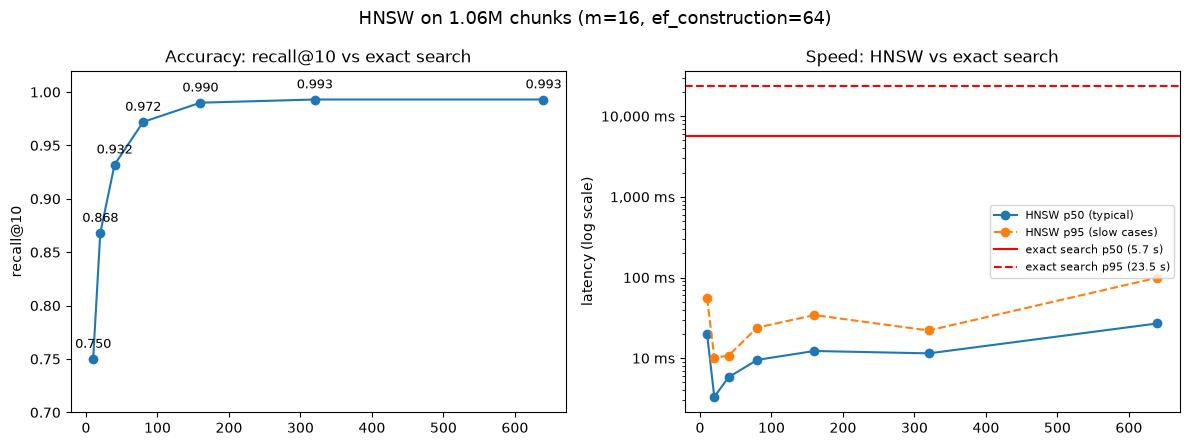

In [22]:
import matplotlib.pyplot as plt

ef = sweep["ef_search"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: accuracy
ax1.plot(ef, sweep["recall@10"], marker="o", color="tab:blue")
for x, y in zip(ef, sweep["recall@10"]):
    ax1.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax1.set_title("Accuracy: recall@10 vs exact search")
ax1.set_ylabel("recall@10")
ax1.set_ylim(0.7, 1.02)

# Right: speed, with exact search as a reference line
exact_p50_ms = seconds.median() * 1000
exact_p95_ms = seconds.quantile(0.95) * 1000

ax2.plot(ef, sweep["p50 (ms)"], marker="o", label="HNSW p50 (typical)")
ax2.plot(ef, sweep["p95 (ms)"], marker="o", linestyle="--", label="HNSW p95 (slow cases)")
ax2.axhline(exact_p50_ms, color="red", label=f"exact search p50 ({exact_p50_ms / 1000:.1f} s)")
ax2.axhline(exact_p95_ms, color="red", linestyle="--", label=f"exact search p95 ({exact_p95_ms / 1000:.1f} s)")
ax2.set_yscale("log")                     # ms for HNSW and seconds for exact search on one chart
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f} ms"))
ax2.set_title("Speed: HNSW vs exact search")
ax2.set_ylabel("latency (log scale)")
ax2.legend(fontsize=8, loc="center right")


fig.suptitle("HNSW on 1.06M chunks (m=16, ef_construction=64)", fontsize=13)
fig.tight_layout()

Path("img").mkdir(exist_ok=True)
fig.savefig("img/hnsw_ef_search.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
CHOSEN_EF = 160      # the value to use in the API

h = sweep.set_index("ef_search").loc[CHOSEN_EF]
exact_p50_ms = seconds.median() * 1000
exact_p95_ms = seconds.quantile(0.95) * 1000

summary = pd.DataFrame({
    "": ["p50 latency", "p95 latency", "recall@10", "speed-up (p50)"],
    "Exact search": [f"{exact_p50_ms / 1000:.1f} s", f"{exact_p95_ms / 1000:.1f} s", "1.000", "—"],
    f"HNSW (ef_search = {CHOSEN_EF})": [
        f"{h['p50 (ms)']:.1f} ms",
        f"{h['p95 (ms)']:.1f} ms",
        f"{h['recall@10']:.3f}",
        f"{exact_p50_ms / h['p50 (ms)']:,.0f}×",
    ],
})
summary.style.hide(axis="index")

,Exact search,HNSW (ef_search = 160)
p50 latency,5.7 s,12.3 ms
p95 latency,23.5 s,34.2 ms
recall@10,1.000,0.990
speed-up (p50),—,460×


## Experiment 4: summary

| | Exact search | HNSW (ef_search = 160) |
|---|---|---|
| p50 latency | 5.7 s | 12.3 ms |
| p95 latency | 23.5 s | 34.2 ms |
| recall@10 | 1.000 | 0.990 |
| Speed-up (p50) | — | **460×** |


**Conclusion:** over 1.06M chunks, HNSW returns 99% of the exact top-10 results about **455× faster** (12 ms instead of 5.6 s). Recall stops improving above `ef_search = 160` (it plateaus at 0.993), so 160 is the value used in the API.

- Exact search latency depends heavily on caching (1.9–36.8 s); HNSW is fastest when its 1.9 GB index stays in memory (~12 ms). When parts of it have to be read from disk, searches are several times slower (~74 ms in our cold runs), though still far faster than exact search. Hence shared_buffers = 2.5 GB.

- Latencies were measured on a laptop under normal load and vary between runs; recall is exact and repeatable.